In [1]:
import numpy as np
from kernelcpd import binseg
import matplotlib.pyplot as plt
import ruptures as rpt

np.random.seed(123)

In [2]:
figure_number = 3

In [3]:
y = np.load(f"signals/{figure_number}.npy")

In [4]:
true_changepoints = [100]

In [5]:
n_bkps = 1

In [6]:
T = 15
laplace_option = "h1"

In [7]:
chpnts_dict = {
    k: np.array(rpt.KernelCPD(kernel=k).fit(y).predict(n_bkps=n_bkps)[:-1])
    for k in ["linear", "rbf", "cosine"]
}
chpnts_dict['label'] = np.array(true_changepoints)
chpnts_dict["proposed"] = binseg(sequence=y, n_changepoints=n_bkps, T=T, laplace_option=laplace_option) + 1

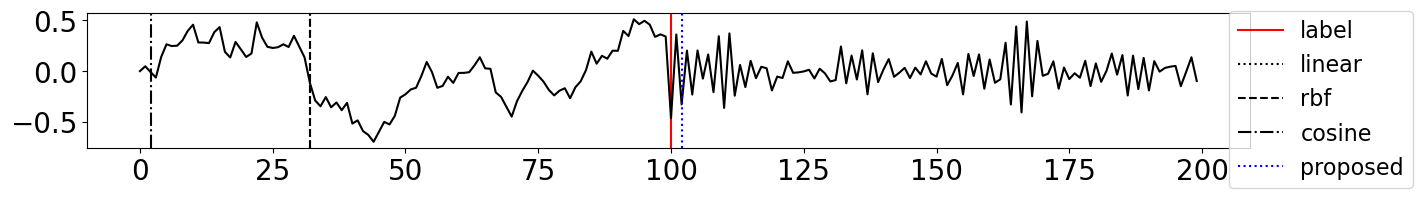

In [8]:
chosen_methods = ["label", "linear", "rbf", "cosine", "proposed"]
chpnts_dict_final = {k: chpnts_dict[k] for k in chosen_methods if k in chpnts_dict}

linestyles = {
    "label": "-",
    "linear": ":",
    "rbf": "--",
    "cosine": "-.",
    "proposed": ":",
}

plt.figure(figsize=(15, 1.75))
plt.plot(y, color="black")

ax = plt.gca()

for method, cps in chpnts_dict_final.items():
    for cp in cps:
        plt.axvline(
            cp,
            linestyle = linestyles.get(method, "--"),
            color = "red" if method == "label" else "blue" if method == "proposed"  else "black",
            zorder = 0    if method == "label" else 10,
            label = method
        )

# remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc="upper right", bbox_to_anchor=(1.15, 1.1), fontsize=16)
plt.tick_params(axis='both', labelsize=20)
plt.show()